Starting Day 1 on 5/25/2026 

In [6]:
import matplotlib.pyplot as plt

In [7]:
words = open('names.txt', 'r').read().splitlines()


In [8]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
print(min(len(w) for w in words))
print(max(len(w) for w in words))

2
15


First we build the Bigram language model. We will be working with a list of names, and we want to learn how to generate new names that look similar to the ones in the list.

In [5]:
b = {}
for w in words[:]:
    chs = ['<S'] + list(w) + ['<E']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
# To figure out how common the characters are next to each other, we are going to count!

In [22]:
# sorted(b.items(), key= lambda kv: -kv[1]) 
# It's going to be convenient for us to use a 2D array instead of a dict

In [2]:
import torch
a = torch.zeros((3, 5), dtype= torch.int32) # since we will only use counts, int is better
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [3]:
# we require a bigger array, that contains all alphabets + two new characters (<S and <E)
N = torch.zeros((28, 28), dtype = torch.int32)

We need a way to convert the characters to numbers

In [37]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)} # enumerate gives index and the element in that index
stoi['<S'] = 26
stoi['<E'] = 27

In [41]:
for w in words[:]:
    chs = ['<S'] + list(w) + ['<E']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [53]:
N[3, 3].item() # gives the direct integer instead of a tensor

149

In [ ]:
itos = {i:s for s, i in stoi.items()}
plt.figure(figsize= (16, 16))
plt.imshow(N, cmap= 'Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color= 'blue')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color= 'red') 
plt.axis('off')

Observe carefully to see that we have a row of 0s where E being the starting char, which never happens and same applied to S being the ending char. Next, we have to tidy up this matrix.

Done Day 1 on 5/25/2026 at 19:53 -> video time (22:10)

Starting Day 2 on 5/26/2026 at 17:52

(28, 28) matrix will be changed to (27, 27) to remove the extra unused character.

In [4]:
N = torch.zeros((27, 27), dtype = torch.int32)

In [57]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)} # enumerate gives index and the element in that index
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
# itos

In [58]:
for w in words[:]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

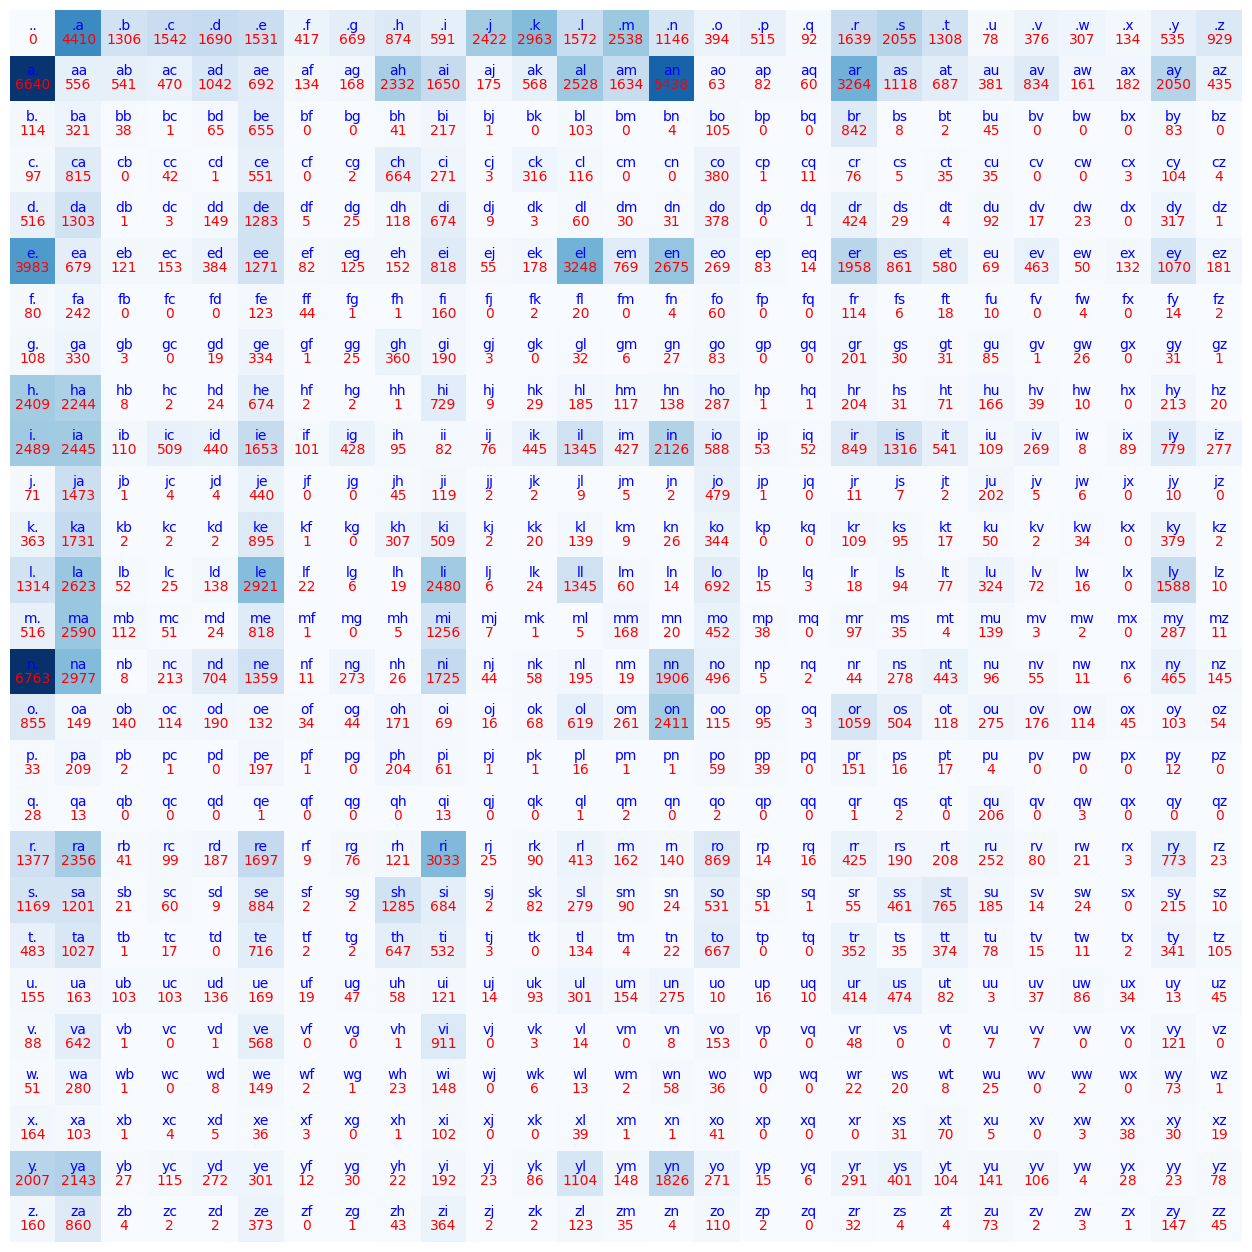

In [11]:
itos = {i:s for s, i in stoi.items()}
plt.figure(figsize= (16, 16))
plt.imshow(N, cmap= 'Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color= 'blue')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color= 'red') 
plt.axis('off')

In [23]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

We want to convert these counts to probabilities to sample them

In [82]:
p = N[0].float() # convert to float for division
p = p / p.sum() # normalize to get probabilities
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [83]:
g = torch.Generator().manual_seed(2147483647) # set the seed for reproducibility
ix = torch.multinomial(p, num_samples = 1, replacement = True, generator=g).item()
itos[ix]

'c'

In [26]:
p.sum() # the sum of probabilities should be 1 

tensor(1.)

Finishd Day 2 on 5/26/2026 at 18:06 -> video time (27:50)

Starting Day 3 on 5/27/2026 at 18:00

In [54]:
g = torch.Generator().manual_seed(2147483647) # set the seed for reproducibility
p = torch.rand(3, generator=g)
p = p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [55]:
torch.multinomial(p, num_samples = 3, replacement = True) # gives us 20 samples from the distribution p, with replacement

tensor([0, 0, 1])

Something to notice here is that, we are sampling from the distribution p, and carefully looking at it's output, you have a 60% chance of getting a 0, 30 % for 1, and 10% for 2. And that's what happens in multinomial sampling!

In [87]:
g = torch.Generator().manual_seed(2147483647) # set the seed for reproducibility

ix = 0
while True:
    p = N[ix].float()
    p = p/ p.sum()
    ix = torch.multinomial(p, num_samples = 1, replacement = True, generator=g).item()
    print(itos[ix], end = '')
    if ix == 0:
        break 

cexze.

Finished Day 3 on 5/27/2026 at 18:34 -> video time (33:24)